# Exploration & Data loading

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)

In [5]:
df = pd.read_csv("../data/raw/telco_customer_churn.csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- based on the .describe (and exploration) we can see that most categorical variables have between 2, 3, or 4 categories
- So for those that only have 2 (binary) let's just replace by 0 and 1
- For those that have 3 or 4 we can do One-Hot encoding

# Binary Encoding

In [7]:
binary_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 2]
binary_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

In [8]:
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

C:\Users\vandan\AppData\Local\Temp\ipykernel_63060\2190479342.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


# One-Hot encoding
For Multiclass encoding >2 

In [9]:
multi_cat_cols = [col for col in df.columns if df[col].nunique(dropna=False) > 2 and df[col].nunique(dropna=False) < 5]
multi_cat_cols



['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [10]:
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# Cleaning

In [11]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')


In [12]:
df = df.drop('customerID', axis=1)

In [13]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int) # converts True/False to 1/0 for all boolean cols

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


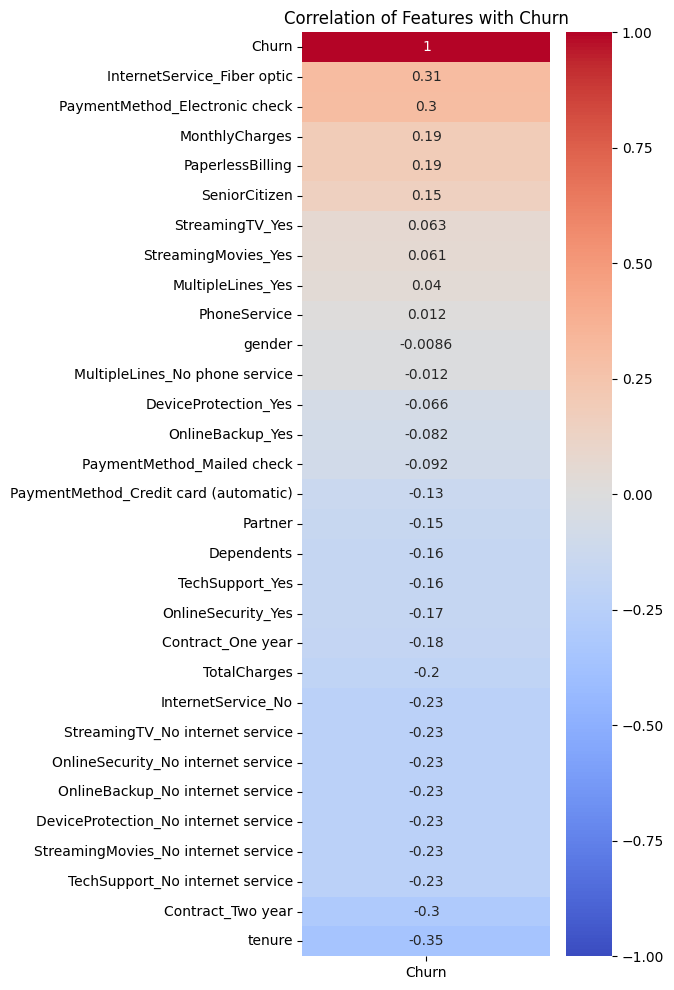

In [16]:
# Correlation Matrix. This will help us understand the relationships between the features and the target variable (Churn).
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()


Negative (lower value → less likely to churn):

- tenure (-0.35) → Customers who stay longer are less likely to churn.
- Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
- Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

Positive (higher value → more likely to churn):

- InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
- PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn mor

### Look for multicolinearity (VIF)

Multicollinearity in Regression, VIF, Causes, Fix, ExamplesMulticollinearity is a statistical phenomenon in regression analysis where two or more independent variables are highly correlated, meaning one can be linearly predicted from the others with high accuracy. This issue makes it difficult to isolate the individual effect of each variable, leading to unreliable, unstable, and hard-to-interpret model results

Examples: 
- Dummy Variable Trap: Including all levels of a categorical variable (e.g., including both "Male" and "Female" columns).
- Similar Metrics: Including "years of experience" and "age" together in a salary model, as they are likely highly correlated.
- Data Collection Issues: Sampling from a limited range where variables appear linearly dependent, such as only sampling high-income individuals for a study on spending habits.

In [17]:
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [18]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


In [19]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

vif_data

e:\Codes\ML\customer-churn-model\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
11,InternetService_No,inf
23,No_internet_service,inf
5,PhoneService,1773.528816
7,MonthlyCharges,866.089640
10,InternetService_Fiber optic,148.500814
24,No_phone_service,60.842267
17,StreamingMovies_Yes,24.156394
16,StreamingTV_Yes,24.080019
8,TotalCharges,10.811490
4,tenure,7.584453


- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

We would be directly using Tree based models in our case.  

# Machine learning

In [20]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important - here’s why:

1. Business context Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave -> you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority

- If retention campaigns are cheap -> prioritize recall (catch every possible churner).
- If retention campaigns are expensive -> balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk -> use ROC-AUC or PR-AUC to evaluate the model.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time


Try with different models and ensemble techniques. To get better recall as this is our goal. It is important to consider tradeoffs with each metrics we need to consider 
As high recall can reduce precision. 
For this use case we consider recall is our priority with precision and F1 score to be balanced and not to deviated. 
Here I tried 3 models.
1. RandomForest
2. Light GBM
3. XGBoost

In [22]:
# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see next to choose the right value)

## RandomForest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



Around 72% Recall 

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.508   0.797   0.620   
0.3     0.531   0.717   0.610   
0.35    0.548   0.668   0.602   
0.4     0.571   0.615   0.592   
0.45    0.601   0.551   0.575   
0.5     0.625   0.489   0.549   


With different threshold to check which gives better results. and 0.3 is good enough

## LightGBM classifier

In [25]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.73 seconds
Prediction time: 0.0084 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733   

Around 82% a very good increase in recall but see the precision dopped to 50% around 3% drop from RF
The cost is a small drop in precision - meaning more loyal customers will be flagged as churn risks - but if retention offers are low-cost, this is fine.

## XGBoost Classifier

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

Training time: 1.07 seconds
Prediction time: 0.0121 seconds
              precision    recall  f1-score   support

           0      0.914     0.687     0.784      1035
           1      0.487     0.821     0.611       374

    accuracy                          0.722      1409
   macro avg      0.700     0.754     0.698      1409
weighted avg      0.800     0.722     0.738      1409



# Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

### For XGBoost 

In [53]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split
import time

In [54]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

In [55]:
# Run Optuna
study_xgboost = optuna.create_study(direction="maximize")
study_xgboost.optimize(xgb_objective, n_trials=30)

print("Best Params:", study_xgboost.best_params)
print("Best Recall:", study_xgboost.best_value)

[I 2026-04-02 23:26:29,284] A new study created in memory with name: no-name-4d101009-88bf-4680-b12b-a3d161cf3f51


[I 2026-04-02 23:26:29,911] Trial 0 finished with value: 0.9171122994652406 and parameters: {'n_estimators': 633, 'learning_rate': 0.06148445093168122, 'max_depth': 6, 'subsample': 0.9561516346761971, 'colsample_bytree': 0.8261820936852595, 'min_child_weight': 7, 'gamma': 3.5240983226875318, 'reg_alpha': 3.4120345073252363, 'reg_lambda': 0.0642173116770961}. Best is trial 0 with value: 0.9171122994652406.
[I 2026-04-02 23:26:31,073] Trial 1 finished with value: 0.8850267379679144 and parameters: {'n_estimators': 635, 'learning_rate': 0.016372965248023674, 'max_depth': 8, 'subsample': 0.747280786888828, 'colsample_bytree': 0.6603036366194474, 'min_child_weight': 7, 'gamma': 1.0684386772929728, 'reg_alpha': 3.194562115050786, 'reg_lambda': 4.431658370748895}. Best is trial 0 with value: 0.9171122994652406.
[I 2026-04-02 23:26:31,455] Trial 2 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 552, 'learning_rate': 0.1823526340276257, 'max_depth': 5, 'subsample': 0.95

Best Params: {'n_estimators': 599, 'learning_rate': 0.029764568912891767, 'max_depth': 7, 'subsample': 0.9986151744056471, 'colsample_bytree': 0.8222538290280027, 'min_child_weight': 7, 'gamma': 2.748129621350892, 'reg_alpha': 2.865104646796413, 'reg_lambda': 3.2393629200000253}
Best Recall: 0.9224598930481284


In [56]:
# calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgboost_best_params = study_xgboost.best_params
xgboost_best_params.update({
    "random_state": 42,
    "scale_pos_weight": scale_pos_weight,
    "n_jobs": -1,
    "eval_metric": "logloss"
})
xgb_best = XGBClassifier(**xgboost_best_params)
start_train = time.time()
xgb_best.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = xgb_best.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

Training time: 0.47 seconds
Prediction time: 0.0095 seconds
              precision    recall  f1-score   support

           0      0.954     0.585     0.725      1035
           1      0.445     0.922     0.601       374

    accuracy                          0.674      1409
   macro avg      0.700     0.754     0.663      1409
weighted avg      0.819     0.674     0.692      1409



### LightGBM

In [57]:
def lightgbm_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.5),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "verbosity": -1,
    }
    
    model = LGBMClassifier(**params)
    
    # ✅ FIX 4: Add callbacks to suppress per-trial warnings
    model.fit(
        X_train, y_train,
    )
    
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

In [58]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(lightgbm_objective, n_trials=30)

print("Best Params:", study_lgbm.best_params)
print("Best Recall:", study_lgbm.best_value)


[I 2026-04-02 23:26:46,615] A new study created in memory with name: no-name-a3046eb2-7cb9-411b-abfc-9bb3beea2767
[I 2026-04-02 23:26:47,351] Trial 0 finished with value: 0.767379679144385 and parameters: {'n_estimators': 528, 'learning_rate': 0.13387778928806712, 'num_leaves': 49, 'subsample': 0.8542556697069972, 'colsample_bytree': 0.7204200341039464, 'min_child_samples': 18, 'reg_alpha': 1.3805368943184644, 'reg_lambda': 1.1900921686768435, 'max_depth': 7}. Best is trial 0 with value: 0.767379679144385.
[I 2026-04-02 23:26:48,291] Trial 1 finished with value: 0.8529411764705882 and parameters: {'n_estimators': 416, 'learning_rate': 0.013966409138708722, 'num_leaves': 77, 'subsample': 0.8298592836255896, 'colsample_bytree': 0.5183220668665729, 'min_child_samples': 18, 'reg_alpha': 0.40973713433521597, 'reg_lambda': 0.4645191494567426, 'max_depth': 10}. Best is trial 1 with value: 0.8529411764705882.
[I 2026-04-02 23:26:48,840] Trial 2 finished with value: 0.7433155080213903 and param

Best Params: {'n_estimators': 477, 'learning_rate': 0.011501927639594761, 'num_leaves': 49, 'subsample': 0.582639232259982, 'colsample_bytree': 0.7304793860320906, 'min_child_samples': 9, 'reg_alpha': 1.4947866878936282, 'reg_lambda': 1.4819993435208523, 'max_depth': 3}
Best Recall: 0.93048128342246


In [59]:
lgbm_best_params = study_lgbm.best_params
lgbm_best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum()
})
lgbm_best = LGBMClassifier(**lgbm_best_params)
start_train = time.time()
lgbm_best.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = lgbm_best.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

Training time: 0.18 seconds
Prediction time: 0.0079 seconds
              precision    recall  f1-score   support

           0      0.956     0.549     0.697      1035
           1      0.427     0.930     0.585       374

    accuracy                          0.650      1409
   macro avg      0.692     0.740     0.641      1409
weighted avg      0.816     0.650     0.668      1409



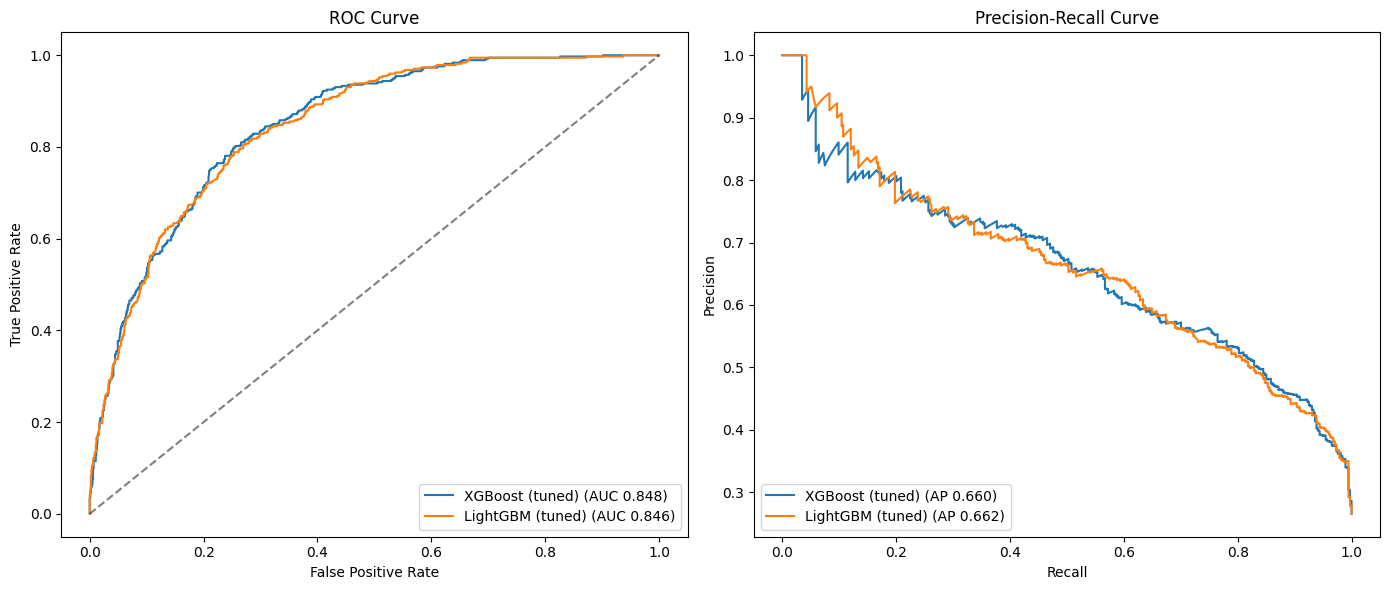

In [60]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

models = {
    "XGBoost (tuned)": xgb_best,
    "LightGBM (tuned)": lgbm_best
}

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()

- PR curve is almost same for LGBM and XGB
- We can choose whichever model we need since there is not much difference.
- I am choosing XGB since we need recall opver precision  